## Comparison of planting with Gilmore data

#### Gilmore site information

lat = 41.05734,  lon = -78.69149

Area = 0.25 ha

Planted: 2021

Visit 1: November 7th 2023

visit 2: October 16th 2024




In [1]:
import numpy as np
import xarray as xr
import csv
import pandas as pd
import os
import netCDF4 as nc4
import sys

import functions_py.fates_xarray_functions as fa

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from matplotlib import cm
import matplotlib.colors as mcolors
from matplotlib.colors import BoundaryNorm
from mpl_toolkits.mplot3d import Axes3D

from shapely.geometry import Polygon

/global/homes/j/jneedham/.conda/envs/myenv/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


#### Load FATES

In [2]:
fates = '/pscratch/sd/j/jneedham/fates-mrv-runs/runs/PA_reforestation.Eddc844b10d-Fe7658331.2025-04-04/run/PA_reforestation.Eddc844b10d-Fe7658331.2025-04-04.sofar.nc'
fates = xr.open_dataset(fates,  decode_times=False)

In [4]:
nyears = int(len(fates.variables['time'])/12)
print(nyears)
time = fates.variables['time'] / 365.

tave_start = (nyears*12-20*12)
tave_stop = nyears*12

cohort_size_bins = fates.variables['fates_levscls'][:]
nsizebins = len(cohort_size_bins)
patch_age_bins = fates.variables['fates_levage'][:]

300


In [5]:
print(cohort_size_bins)

<xarray.IndexVariable 'fates_levscls' (fates_levscls: 13)>
array([  0.,   5.,  10.,  15.,  20.,  30.,  40.,  50.,  60.,  70.,  80.,  90.,
       100.], dtype=float32)
Attributes:
    long_name:  FATES diameter size class lower bound
    units:      cm


#### Load data

In [6]:
df_orig = pd.read_csv('/global/homes/j/jneedham/FATES-MRV/gilmore_data/Gilmore_data.csv')

In [7]:
df_orig = df_orig[df_orig.columns.drop(list(df_orig.filter(regex='Unnamed')))]

In [8]:
df_orig.head(3)

,Name,Status,Root Collar Diameter (CM) Time of Planting,SPAD Time of Planting,Height (CM) Time of Planting,Height (cm) July 15 2022,Measurements 08/02,Height (cm) October 15,RCD (mm) November 8th,"Alive/Dead Nov. 7, 2023","RCD (mm) Nov. 7, 2023","DBH (mm) Nov. 7, 2023","Height (cm) Nov. 7, 2023",RCD Growth (2022 - 2023)
0,Gilmore PA.N.M.C.N.1,Alive,0.38,NaN,10.16,NaN,15.24,15.24,4.9,0.0,NaN,NaN,NaN,NaN
1,Gilmore PA.N.M.R.N.2,Alive,0.43,NaN,15.88,NaN,30.48,66.04,0.8,1.0,12.0,11.0,280.0,11.2
2,Gilmore PA.N.M.CR.N.3,Alive,0.38,NaN,15.24,NaN,45.72,91.44,5.7,1.0,9.0,7.0,179.0,3.3


In [9]:
gilmore_area = 0.25

### Mean height at planting (cm)

In [10]:
hmean_planting = df_orig['Height (CM) Time of Planting'].mean()
print(hmean_planting)

22.144380530973432


### 2023 - 2024 Data

In [11]:
df = pd.read_csv('/global/homes/j/jneedham/FATES-MRV/gilmore_data/MRV_Gilmore_2024.csv')

In [12]:
df.head(3)

,tree,RCD10cm_24,D130cm_24,Hm_24,RCD10cm_23,D130cm_23,Hm_23,RCD_24-23,DBH 24-23,H 24-23
0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2.1,1.75,3.37,1.2,1.1,2.80,0.9,0.65,0.57
2,3,1.3,1.10,2.62,0.9,0.7,1.79,0.4,0.40,0.83


### Size distribution 

In [19]:
sizedist_data = pd.cut(df['D130cm_24'], cohort_size_bins.values).value_counts()

# convert to per ha?
sizedist_data_perha = sizedist_data.values / gilmore_area
print(sizedist_data_perha)

[836.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]


In [14]:
print(sizedist_data)

(0.0, 5.0]       209
(5.0, 10.0]        0
(10.0, 15.0]       0
(15.0, 20.0]       0
(20.0, 30.0]       0
(30.0, 40.0]       0
(40.0, 50.0]       0
(50.0, 60.0]       0
(60.0, 70.0]       0
(70.0, 80.0]       0
(80.0, 90.0]       0
(90.0, 100.0]      0
Name: D130cm_24, dtype: int64


In [17]:
nplant_3yrs = fates.FATES_NPLANT_SZ.isel(time=36) * 10000

In [18]:
nplant_3yrs

<xarray.DataArray 'FATES_NPLANT_SZ' (fates_levscls: 13, lndgrid: 1)>
array([[6515.922],
       [   0.   ],
       [   0.   ],
       [   0.   ],
       [   0.   ],
       [   0.   ],
       [   0.   ],
       [   0.   ],
       [   0.   ],
       [   0.   ],
       [   0.   ],
       [   0.   ],
       [   0.   ]], dtype=float32)
Coordinates:
  * fates_levscls  (fates_levscls) float32 0.0 5.0 10.0 15.0 ... 80.0 90.0 100.0
    time           float32 1.126e+03
Dimensions without coordinates: lndgrid

###  Growth rates

In [56]:
gr  = fates.FATES_DDBH_CANOPY_SZPF.sum(dim='fates_levscpf') / fates.FATES_NPLANT_CANOPY_SZPF.sum(dim='fates_levscpf')
print(gr)
gr = gr.isel(time=slice(36,48)).mean(dim='time')
print(gr)


<xarray.DataArray (time: 3600, lndgrid: 1)>
array([[0.0000000e+00],
       [0.0000000e+00],
       [9.8134399e-07],
       ...,
       [6.1579067e-03],
       [9.6988835e-04],
       [0.0000000e+00]], dtype=float32)
Coordinates:
  * time     (time) float32 31.0 59.0 90.0 ... 1.094e+05 1.095e+05 1.095e+05
Dimensions without coordinates: lndgrid
<xarray.DataArray (lndgrid: 1)>
array([0.00802054], dtype=float32)
Dimensions without coordinates: lndgrid


Text(0, 0.5, 'Frequency')

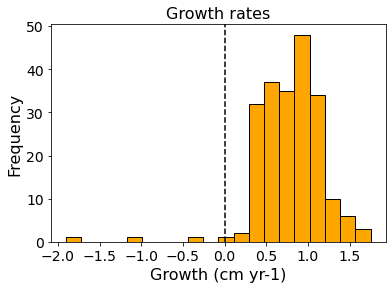

In [58]:
ax = df['DBH 24-23'].hist(grid=False, xlabelsize=14, ylabelsize=14,
                         bins=20,edgecolor='black',
                         color='orange')
ax.axvline(x=gr, color='black', linestyle='--')
# Add a bold title ('\n' allow us to jump rows)
ax.set_title('Growth rates', fontsize=16) 

# Add label names
ax.set_xlabel('Growth (cm yr-1)', fontsize=16)
ax.set_ylabel('Frequency', fontsize=16)